In [27]:
import pandas as pd
import numpy as np
import os

In [29]:
os.listdir()

['.ipynb_checkpoints',
 'DIM_CALENDAR (2).xlsx',
 'DIM_CATEGORY (2).csv',
 'DIM_PRODUCT (1).xlsx',
 'DIM_SEGMENT (1).xlsx',
 'FACT_SALES (1).csv',
 'Proyecto Empresa Aliada Entregable 6-CD-Juan Carlos Kern.docx',
 'Untitled.ipynb']

In [31]:
# 3. Cargar los cinco archivos que conforman la base de datos
dim_calendar = pd.read_excel('DIM_CALENDAR (2).xlsx')
dim_category = pd.read_csv('DIM_CATEGORY (2).csv')
dim_product = pd.read_excel('DIM_PRODUCT (1).xlsx')
dim_segment = pd.read_excel('DIM_SEGMENT (1).xlsx')
fact_sales = pd.read_csv('FACT_SALES (1).csv')

In [33]:
# 4. Revisar el número de filas, columnas y los nombres de las variables de cada archivo

datasets = {
    'DIM_CALENDAR': dim_calendar,
    'DIM_CATEGORY': dim_category,
    'DIM_PRODUCT': dim_product,
    'DIM_SEGMENT': dim_segment,
    'FACT_SALES': fact_sales
}

for nombre, df in datasets.items():
    print(f'\n{nombre}')
    print(f'Dimensiones: {df.shape}')
    print('Columnas:')
    print(df.columns.tolist())


DIM_CALENDAR
Dimensiones: (156, 5)
Columnas:
['WEEK', 'YEAR', 'MONTH', 'WEEK_NUMBER', 'DATE']

DIM_CATEGORY
Dimensiones: (5, 2)
Columnas:
['ID_CATEGORY', 'CATEGORY']

DIM_PRODUCT
Dimensiones: (505, 9)
Columnas:
['MANUFACTURER', 'BRAND', 'ITEM', 'ITEM_DESCRIPTION', 'CATEGORY', 'FORMAT', 'ATTR1', 'ATTR2', 'ATTR3']

DIM_SEGMENT
Dimensiones: (53, 6)
Columnas:
['CATEGORY', 'ATTR1', 'ATTR2', 'ATTR3', 'FORMAT', 'SEGMENT']

FACT_SALES
Dimensiones: (122002, 6)
Columnas:
['WEEK', 'ITEM_CODE', 'TOTAL_UNIT_SALES', 'TOTAL_VALUE_SALES', 'TOTAL_UNIT_AVG_WEEKLY_SALES', 'REGION']


In [35]:
# 5. Ajustar y estandarizar los nombres de las columnas

dim_calendar = dim_calendar.rename(columns={
    'WEEK': 'WeekCode',
    'YEAR': 'Year',
    'MONTH': 'Month',
    'WEEK_NUMBER': 'WeekNumber',
    'DATE': 'Date'
})

dim_category = dim_category.rename(columns={
    'ID_CATEGORY': 'CategoryID',
    'CATEGORY': 'CategoryName'
})

dim_product = dim_product.rename(columns={
    'MANUFACTURER': 'Manufacturer',
    'BRAND': 'Brand',
    'ITEM': 'ItemCode',
    'ITEM_DESCRIPTION': 'ItemDescription',
    'CATEGORY': 'CategoryID',
    'FORMAT': 'Format',
    'ATTR1': 'Attr1',
    'ATTR2': 'Attr2',
    'ATTR3': 'Attr3'
})

dim_segment = dim_segment.rename(columns={
    'CATEGORY': 'CategoryID',
    'ATTR1': 'Attr1',
    'ATTR2': 'Attr2',
    'ATTR3': 'Attr3',
    'FORMAT': 'Format',
    'SEGMENT': 'Segment'
})

fact_sales = fact_sales.rename(columns={
    'WEEK': 'WeekCode',
    'ITEM_CODE': 'ItemCode',
    'TOTAL_UNIT_SALES': 'TotalUnitSales',
    'TOTAL_VALUE_SALES': 'TotalValueSales',
    'TOTAL_UNIT_AVG_WEEKLY_SALES': 'TotalUnitAvgWeeklySales',
    'REGION': 'Region'
})

In [37]:
# 6. Verificar los nuevos nombres de las columnas

datasets = {
    'DIM_CALENDAR': dim_calendar,
    'DIM_CATEGORY': dim_category,
    'DIM_PRODUCT': dim_product,
    'DIM_SEGMENT': dim_segment,
    'FACT_SALES': fact_sales
}

for nombre, df in datasets.items():
    print(f'\n{nombre}')
    print(df.columns.tolist())


DIM_CALENDAR
['WeekCode', 'Year', 'Month', 'WeekNumber', 'Date']

DIM_CATEGORY
['CategoryID', 'CategoryName']

DIM_PRODUCT
['Manufacturer', 'Brand', 'ItemCode', 'ItemDescription', 'CategoryID', 'Format', 'Attr1', 'Attr2', 'Attr3']

DIM_SEGMENT
['CategoryID', 'Attr1', 'Attr2', 'Attr3', 'Format', 'Segment']

FACT_SALES
['WeekCode', 'ItemCode', 'TotalUnitSales', 'TotalValueSales', 'TotalUnitAvgWeeklySales', 'Region']


In [39]:
# 7. Revisar los tipos de datos y la cantidad de valores nulos

for nombre, df in datasets.items():
    print(f'\n{"="*50}')
    print(nombre)
    print(f'{"="*50}')

    print('\nTipos de datos:')
    print(df.dtypes)

    print('\nValores nulos:')
    print(df.isnull().sum())


DIM_CALENDAR

Tipos de datos:
WeekCode              object
Year                   int64
Month                  int64
WeekNumber             int64
Date          datetime64[ns]
dtype: object

Valores nulos:
WeekCode      0
Year          0
Month         0
WeekNumber    0
Date          0
dtype: int64

DIM_CATEGORY

Tipos de datos:
CategoryID       int64
CategoryName    object
dtype: object

Valores nulos:
CategoryID      0
CategoryName    0
dtype: int64

DIM_PRODUCT

Tipos de datos:
Manufacturer       object
Brand              object
ItemCode           object
ItemDescription    object
CategoryID          int64
Format             object
Attr1              object
Attr2              object
Attr3              object
dtype: object

Valores nulos:
Manufacturer       0
Brand              0
ItemCode           2
ItemDescription    0
CategoryID         0
Format             0
Attr1              6
Attr2              0
Attr3              6
dtype: int64

DIM_SEGMENT

Tipos de datos:
CategoryID     int6

In [41]:
# 8. Revisar si las llaves de las tablas dimensionales contienen duplicados

print('DIM_CALENDAR')
print('Filas:', len(dim_calendar))
print('WeekCode únicos:', dim_calendar['WeekCode'].nunique())
print('WeekCode duplicados:', dim_calendar['WeekCode'].duplicated().sum())

print('\nDIM_PRODUCT')
print('Filas:', len(dim_product))
print('ItemCode únicos:', dim_product['ItemCode'].nunique())
print('ItemCode duplicados:', dim_product['ItemCode'].duplicated().sum())

print('\nDIM_CATEGORY')
print('Filas:', len(dim_category))
print('CategoryID únicos:', dim_category['CategoryID'].nunique())
print('CategoryID duplicados:', dim_category['CategoryID'].duplicated().sum())

print('\nDIM_SEGMENT')

segment_keys = ['CategoryID', 'Attr1', 'Attr2', 'Attr3', 'Format']

print('Filas:', len(dim_segment))
print(
    'Combinaciones únicas:',
    dim_segment[segment_keys].drop_duplicates().shape[0]
)
print(
    'Combinaciones duplicadas:',
    dim_segment.duplicated(subset=segment_keys).sum()
)

DIM_CALENDAR
Filas: 156
WeekCode únicos: 156
WeekCode duplicados: 0

DIM_PRODUCT
Filas: 505
ItemCode únicos: 503
ItemCode duplicados: 1

DIM_CATEGORY
Filas: 5
CategoryID únicos: 5
CategoryID duplicados: 0

DIM_SEGMENT
Filas: 53
Combinaciones únicas: 53
Combinaciones duplicadas: 0


In [43]:
# 9. Verificar que las llaves de FACT_SALES tengan correspondencia en las dimensiones

items_sin_producto = fact_sales.loc[
    ~fact_sales['ItemCode'].isin(dim_product['ItemCode']),
    'ItemCode'
].nunique()

semanas_sin_calendario = fact_sales.loc[
    ~fact_sales['WeekCode'].isin(dim_calendar['WeekCode']),
    'WeekCode'
].nunique()

print('ItemCode de FACT_SALES sin correspondencia en DIM_PRODUCT:',
      items_sin_producto)

print('WeekCode de FACT_SALES sin correspondencia en DIM_CALENDAR:',
      semanas_sin_calendario)

ItemCode de FACT_SALES sin correspondencia en DIM_PRODUCT: 0
WeekCode de FACT_SALES sin correspondencia en DIM_CALENDAR: 0


In [45]:
# 10. Revisar los registros con valores nulos en DIM_PRODUCT

productos_con_nulos = dim_product[
    dim_product[['ItemCode', 'Attr1', 'Attr3']].isnull().any(axis=1)
]

productos_con_nulos

,Manufacturer,Brand,ItemCode,ItemDescription,CategoryID,Format,Attr1,Attr2,Attr3
33,WHITE MAGIC,WHITE MAGIC,0079893431208,9WHITE MAGIC BOT.PLAS 3970ML IMP 0079893431208,1,LIQUIDO,NaN,CLORO,NaN
107,INDS. ALEN,CLORALEX,7501025401023,CLORALEX EXTRA SENSACION FRUTALES BOT PLAST 95...,1,LIQUIDO,NaN,CLORO,NaN
143,INDS. ALEN,BLANCATEL,7501025402259,BLANCATEL BLANQUEADOR BOTELLA 1.8LT 7501025402259,1,LIQUIDO,NaN,CLORO,NaN
343,CLOROX,CLOROX,7501071901591,CLOROX BLANQUEADOR PARAISO TROPICAL 3800 ML NA...,1,LIQUIDO,NaN,CLORO,NaN
469,OTHERS FABRICANTE UNIF.,OTHERS MARCA UNIF.,7502217411776,KLEEN CLORO BOTELLA 1000 ML NAL 7502217411776,1,LIQUIDO,NaN,CLORO,NaN
495,IBERIA,IBERIA,8411660040503,9IBERIA BLANQUEADOR POLVO 250 GR IMP 841166004...,1,POLVO,NaN,CLORO,NaN
502,INDS. ALEN,CLORALEX,NaN,CLORALEX EL RENDIDOR BOT PLAST 2LT,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
503,CLOROX,CLOROX,NaN,CLOROX MASCOTAS BLANQUEADOR+DETERGENTE GALON 10L,1,LIQUIDO,CLORO,CLORO,MASCOTAS


In [47]:
# 11. Verificar si existen ItemCode duplicados reales, excluyendo valores nulos

itemcode_duplicados_reales = dim_product[
    dim_product['ItemCode'].notna() &
    dim_product['ItemCode'].duplicated(keep=False)
]

print('ItemCode duplicados reales:', len(itemcode_duplicados_reales))

itemcode_duplicados_reales

ItemCode duplicados reales: 0


,Manufacturer,Brand,ItemCode,ItemDescription,CategoryID,Format,Attr1,Attr2,Attr3


In [49]:
# 12. Verificar la correspondencia de los productos con categorías y segmentos

categorias_sin_correspondencia = dim_product.loc[
    ~dim_product['CategoryID'].isin(dim_category['CategoryID']),
    'CategoryID'
].nunique()

segment_check = dim_product.merge(
    dim_segment,
    on=['CategoryID', 'Attr1', 'Attr2', 'Attr3', 'Format'],
    how='left',
    indicator=True
)

productos_sin_segmento = segment_check[
    segment_check['_merge'] == 'left_only'
]

print(
    'CategoryID de DIM_PRODUCT sin correspondencia en DIM_CATEGORY:',
    categorias_sin_correspondencia
)

print(
    'Productos sin correspondencia en DIM_SEGMENT:',
    len(productos_sin_segmento)
)

CategoryID de DIM_PRODUCT sin correspondencia en DIM_CATEGORY: 0
Productos sin correspondencia en DIM_SEGMENT: 6


In [53]:
# 13. Preparar DIM_PRODUCT eliminando únicamente registros sin ItemCode

dim_product_merge = dim_product.dropna(
    subset=['ItemCode']
).copy()

print('Filas originales de DIM_PRODUCT:', len(dim_product))
print('Filas disponibles para el merge:', len(dim_product_merge))
print(
    'ItemCode duplicados:',
    dim_product_merge['ItemCode'].duplicated().sum()
)

Filas originales de DIM_PRODUCT: 505
Filas disponibles para el merge: 503
ItemCode duplicados: 0


In [55]:
# 14. Consolidar FACT_SALES con las tablas dimensionales

df_consolidado = (
    fact_sales
    .merge(
        dim_product_merge,
        on='ItemCode',
        how='left',
        validate='many_to_one'
    )
    .merge(
        dim_calendar,
        on='WeekCode',
        how='left',
        validate='many_to_one'
    )
    .merge(
        dim_category,
        on='CategoryID',
        how='left',
        validate='many_to_one'
    )
    .merge(
        dim_segment,
        on=['CategoryID', 'Attr1', 'Attr2', 'Attr3', 'Format'],
        how='left',
        validate='many_to_one'
    )
)

In [57]:
# 15. Verificar que no se hayan perdido ni multiplicado registros

print('Filas originales de FACT_SALES:', len(fact_sales))
print('Filas del dataset consolidado:', len(df_consolidado))
print('Columnas del dataset consolidado:', df_consolidado.shape[1])

print('\nDimensiones del dataset consolidado:')
print(df_consolidado.shape)

Filas originales de FACT_SALES: 122002
Filas del dataset consolidado: 122002
Columnas del dataset consolidado: 20

Dimensiones del dataset consolidado:
(122002, 20)


In [59]:
# 16. Visualizar las primeras filas del dataset consolidado

df_consolidado.head()

,WeekCode,ItemCode,TotalUnitSales,TotalValueSales,TotalUnitAvgWeeklySales,Region,Manufacturer,Brand,ItemDescription,CategoryID,Format,Attr1,Attr2,Attr3,Year,Month,WeekNumber,Date,CategoryName,Segment
0,34-22,7501058792808BP2,0.006,0.139,1.000,TOTAL AUTOS AREA 5,RECKITT,VANISH,VANISHOXIACTIONROSADOYPACK120GR+MMCRYSTALWHITE...,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,2022,8,34,2022-08-28,FABRIC TREATMENT and SANIT\r\n,POWDER
1,34-22,7501058715883,0.487,116.519,2.916,TOTAL AUTOS AREA 5,RECKITT,VANISH,VANISH OXI ACTION GOLD QUITAMANCHAS BOLSA 1.8K...,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,2022,8,34,2022-08-28,FABRIC TREATMENT and SANIT\r\n,POWDER
2,34-22,7702626213774,1.391,68.453,5.171,TOTAL AUTOS AREA 5,RECKITT,VANISH,VANISH OXI ACTION ROSA QUITAMANCHAS DOYPACK 24...,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,2022,8,34,2022-08-28,FABRIC TREATMENT and SANIT\r\n,POWDER
3,34-22,7501058716422,0.022,1.481,1.833,TOTAL AUTOS AREA 5,RECKITT,VANISH,VANISH OXI ACTION GOLD QUITAMANCHA AHORRO DEL ...,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,2022,8,34,2022-08-28,FABRIC TREATMENT and SANIT\r\n,POWDER
4,34-22,7501058784353,2.037,182.839,5.375,TOTAL AUTOS AREA 5,RECKITT,VANISH,VANISH INTELLIGENCE POLVO BOTE 450 GR NAL 7501...,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,2022,8,34,2022-08-28,FABRIC TREATMENT and SANIT\r\n,POWDER


In [61]:
# 17. Revisar la cantidad de valores nulos en el dataset consolidado

df_consolidado.isnull().sum()

WeekCode                   0
ItemCode                   0
TotalUnitSales             0
TotalValueSales            0
TotalUnitAvgWeeklySales    0
Region                     0
Manufacturer               0
Brand                      0
ItemDescription            0
CategoryID                 0
Format                     0
Attr1                      0
Attr2                      0
Attr3                      0
Year                       0
Month                      0
WeekNumber                 0
Date                       0
CategoryName               0
Segment                    0
dtype: int64

In [63]:
# 18. Revisar cuántas observaciones de ventas quedaron sin segmento

ventas_sin_segmento = df_consolidado[
    df_consolidado['Segment'].isnull()
]

print('Observaciones sin segmento:', len(ventas_sin_segmento))

print('\nProductos involucrados:')
print(
    ventas_sin_segmento[
        ['ItemCode', 'Brand', 'ItemDescription', 'Attr1', 'Attr2', 'Attr3', 'Format']
    ]
    .drop_duplicates()
)

Observaciones sin segmento: 0

Productos involucrados:
Empty DataFrame
Columns: [ItemCode, Brand, ItemDescription, Attr1, Attr2, Attr3, Format]
Index: []


In [65]:
# 19. Revisar el periodo histórico disponible en el dataset

print('Fecha inicial:', df_consolidado['Date'].min())
print('Fecha final:', df_consolidado['Date'].max())
print('Número de semanas:', df_consolidado['WeekCode'].nunique())

Fecha inicial: 2022-01-09 00:00:00
Fecha final: 2023-07-17 00:00:00
Número de semanas: 80


In [67]:
# 20. Buscar productos relacionados con Vanish y Lysol

productos_objetivo = df_consolidado[
    df_consolidado['Brand'].astype(str).str.contains(
        'VANISH|LYSOL',
        case=False,
        na=False
    ) |
    df_consolidado['ItemDescription'].astype(str).str.contains(
        'VANISH|LYSOL',
        case=False,
        na=False
    )
]

print('Observaciones encontradas:', len(productos_objetivo))

productos_objetivo[
    ['Manufacturer', 'Brand', 'ItemCode', 'ItemDescription', 'CategoryName']
].drop_duplicates()

Observaciones encontradas: 31826


,Manufacturer,Brand,ItemCode,ItemDescription,CategoryName
0,RECKITT,VANISH,7501058792808BP2,VANISHOXIACTIONROSADOYPACK120GR+MMCRYSTALWHITE...,FABRIC TREATMENT and SANIT\r\n
1,RECKITT,VANISH,7501058715883,VANISH OXI ACTION GOLD QUITAMANCHAS BOLSA 1.8K...,FABRIC TREATMENT and SANIT\r\n
2,RECKITT,VANISH,7702626213774,VANISH OXI ACTION ROSA QUITAMANCHAS DOYPACK 24...,FABRIC TREATMENT and SANIT\r\n
3,RECKITT,VANISH,7501058716422,VANISH OXI ACTION GOLD QUITAMANCHA AHORRO DEL ...,FABRIC TREATMENT and SANIT\r\n
4,RECKITT,VANISH,7501058784353,VANISH INTELLIGENCE POLVO BOTE 450 GR NAL 7501...,FABRIC TREATMENT and SANIT\r\n
...,...,...,...,...,...
9313,RECKITT,VANISH,7501058782694BP1,VANISH OXI ACTION QUITAMANCHAS BOT 450G C/GMM ...,FABRIC TREATMENT and SANIT\r\n
10217,RECKITT,VANISH,7501058753205,VANISH EXTRA-HIGIENE BOTELLA PLASTICO 900 ML 7...,FABRIC TREATMENT and SANIT\r\n
31271,RECKITT,VANISH,7501058784889,VANISH MAX 3 BOT 925ML C /U=2775ML LLEVA 3 PAG...,FABRIC TREATMENT and SANIT\r\n
56526,RECKITT,VANISH,7501058789778BP1,VANISH EXT HIGIENE REM MANCHAS GAL 4LT + VANIS...,FABRIC TREATMENT and SANIT\r\n


In [69]:
# 21. Revisar la cantidad de observaciones y productos por marca objetivo

resumen_marcas = (
    productos_objetivo
    .groupby('Brand')
    .agg(
        Observaciones=('ItemCode', 'size'),
        Productos=('ItemCode', 'nunique'),
        FechaInicial=('Date', 'min'),
        FechaFinal=('Date', 'max'),
        Semanas=('WeekCode', 'nunique')
    )
    .reset_index()
)

resumen_marcas

,Brand,Observaciones,Productos,FechaInicial,FechaFinal,Semanas
0,LYSOL,3449,8,2022-01-09,2023-07-17,80
1,VANISH,28377,77,2022-01-09,2023-07-17,80


In [71]:
# 22. Mostrar las marcas encontradas dentro de los productos objetivo

print('Marcas encontradas:')
print(productos_objetivo['Brand'].value_counts())

Marcas encontradas:
Brand
VANISH    28377
LYSOL      3449
Name: count, dtype: int64


In [73]:
# 23. Revisar las regiones disponibles en los productos objetivo

print('Número de regiones:')
print(productos_objetivo['Region'].nunique())

print('\nRegiones disponibles:')
print(
    productos_objetivo['Region']
    .value_counts()
)

Número de regiones:
7

Regiones disponibles:
Region
TOTAL AUTOS SCANNING MEXICO    5271
TOTAL AUTOS AREA 2             4821
TOTAL AUTOS AREA 5             4417
TOTAL AUTOS AREA 4             4415
TOTAL AUTOS AREA 6             4413
TOTAL AUTOS AREA 3             4271
TOTAL AUTOS AREA 1             4218
Name: count, dtype: int64


In [75]:
# 24. Verificar la estructura de las ventas por producto, semana y región

estructura_ventas = (
    productos_objetivo
    .groupby(['Brand', 'ItemCode', 'WeekCode', 'Region'])
    .size()
    .reset_index(name='Registros')
)

print('Máximo de registros para una misma combinación:')
print(estructura_ventas['Registros'].max())

print('\nCombinaciones con más de un registro:')
print((estructura_ventas['Registros'] > 1).sum())

Máximo de registros para una misma combinación:
1

Combinaciones con más de un registro:
0


In [77]:
# 25. Comparar TOTAL AUTOS SCANNING MEXICO contra la suma de las áreas 1 a 6

ventas_nacional = (
    productos_objetivo[
        productos_objetivo['Region'] == 'TOTAL AUTOS SCANNING MEXICO'
    ]
    .groupby(['Brand', 'ItemCode', 'WeekCode'], as_index=False)
    ['TotalUnitSales']
    .sum()
    .rename(columns={'TotalUnitSales': 'VentasNacional'})
)

ventas_areas = (
    productos_objetivo[
        productos_objetivo['Region'] != 'TOTAL AUTOS SCANNING MEXICO'
    ]
    .groupby(['Brand', 'ItemCode', 'WeekCode'], as_index=False)
    ['TotalUnitSales']
    .sum()
    .rename(columns={'TotalUnitSales': 'VentasAreas'})
)

comparacion_regiones = ventas_nacional.merge(
    ventas_areas,
    on=['Brand', 'ItemCode', 'WeekCode'],
    how='inner'
)

comparacion_regiones['Diferencia'] = (
    comparacion_regiones['VentasNacional']
    - comparacion_regiones['VentasAreas']
)

comparacion_regiones.head()

,Brand,ItemCode,WeekCode,VentasNacional,VentasAreas,Diferencia
0,LYSOL,0019200958714,21-22,0.001,0.001,0.0
1,LYSOL,0019200958714,32-22,0.001,0.001,0.0
2,LYSOL,7501058717115,01-22,0.875,0.875,0.0
3,LYSOL,7501058717115,01-23,0.052,0.052,0.0
4,LYSOL,7501058717115,02-22,1.284,1.284,0.0


In [79]:
# 26. Evaluar la relación entre el total nacional y la suma de las áreas

print('Número de comparaciones:', len(comparacion_regiones))

print(
    '\nDiferencia absoluta promedio:',
    comparacion_regiones['Diferencia'].abs().mean()
)

print(
    'Diferencia absoluta mediana:',
    comparacion_regiones['Diferencia'].abs().median()
)

print(
    '\nCorrelación entre Total Nacional y Suma de Áreas:',
    comparacion_regiones[
        ['VentasNacional', 'VentasAreas']
    ].corr().iloc[0, 1]
)

Número de comparaciones: 5271

Diferencia absoluta promedio: 9.599696452296747e-05
Diferencia absoluta mediana: 0.0

Correlación entre Total Nacional y Suma de Áreas: 0.9999999995591571


In [81]:
# 27. Visualizar ejemplos de Total Nacional vs Suma de Áreas

comparacion_regiones[
    [
        'Brand',
        'ItemCode',
        'WeekCode',
        'VentasNacional',
        'VentasAreas',
        'Diferencia'
    ]
].head(20)

,Brand,ItemCode,WeekCode,VentasNacional,VentasAreas,Diferencia
0,LYSOL,0019200958714,21-22,0.001,0.001,0.000000e+00
1,LYSOL,0019200958714,32-22,0.001,0.001,0.000000e+00
2,LYSOL,7501058717115,01-22,0.875,0.875,0.000000e+00
3,LYSOL,7501058717115,01-23,0.052,0.052,0.000000e+00
4,LYSOL,7501058717115,02-22,1.284,1.284,0.000000e+00
5,LYSOL,7501058717115,02-23,0.045,0.045,0.000000e+00
6,LYSOL,7501058717115,03-22,1.220,1.220,0.000000e+00
7,LYSOL,7501058717115,03-23,0.050,0.050,0.000000e+00
8,LYSOL,7501058717115,04-22,1.176,1.176,0.000000e+00
9,LYSOL,7501058717115,04-23,0.027,0.027,0.000000e+00


In [83]:
# 28. Seleccionar las ventas nacionales de Vanish y Lysol

ventas_nacionales = productos_objetivo[
    productos_objetivo['Region'] == 'TOTAL AUTOS SCANNING MEXICO'
].copy()

print('Observaciones nacionales:', len(ventas_nacionales))

print('\nObservaciones por marca:')
print(ventas_nacionales['Brand'].value_counts())

Observaciones nacionales: 5271

Observaciones por marca:
Brand
VANISH    4751
LYSOL      520
Name: count, dtype: int64


In [85]:
# 29. Agrupar las ventas nacionales por fecha y marca

ventas_semanales = (
    ventas_nacionales
    .groupby(['Date', 'Brand'], as_index=False)
    ['TotalUnitSales']
    .sum()
    .sort_values('Date')
)

ventas_semanales.head(10)

,Date,Brand,TotalUnitSales
0,2022-01-09,LYSOL,6.479
1,2022-01-09,VANISH,360.805
2,2022-01-16,LYSOL,8.621
3,2022-01-16,VANISH,340.576
4,2022-01-23,LYSOL,8.478
5,2022-01-23,VANISH,290.182
6,2022-01-30,LYSOL,8.201
7,2022-01-30,VANISH,290.540
9,2022-02-06,VANISH,311.736
8,2022-02-06,LYSOL,5.914


In [87]:
# 30. Crear una tabla temporal con una columna para cada marca

serie_ventas = (
    ventas_semanales
    .pivot(
        index='Date',
        columns='Brand',
        values='TotalUnitSales'
    )
    .sort_index()
)

serie_ventas.head(10)

Brand,LYSOL,VANISH
Date,,
2022-01-09,6.479,360.805
2022-01-16,8.621,340.576
2022-01-23,8.478,290.182
2022-01-30,8.201,290.540
2022-02-06,5.914,311.736
2022-02-13,4.575,286.168
2022-02-20,3.993,326.963
2022-02-27,3.467,318.586
2022-03-06,3.237,366.021


In [89]:
# 31. Verificar la estructura y continuidad de las series temporales

print('Dimensiones:')
print(serie_ventas.shape)

print('\nFecha inicial:')
print(serie_ventas.index.min())

print('\nFecha final:')
print(serie_ventas.index.max())

print('\nValores nulos:')
print(serie_ventas.isnull().sum())

print('\nNúmero de semanas:')
print(len(serie_ventas))

Dimensiones:
(80, 2)

Fecha inicial:
2022-01-09 00:00:00

Fecha final:
2023-07-17 00:00:00

Valores nulos:
Brand
LYSOL     0
VANISH    0
dtype: int64

Número de semanas:
80


In [91]:
# 32. Verificar la frecuencia temporal entre las observaciones

diferencias_fechas = (
    serie_ventas.index
    .to_series()
    .diff()
    .value_counts()
)

print('Diferencias entre fechas consecutivas:')
print(diferencias_fechas)

Diferencias entre fechas consecutivas:
Date
7 days    78
8 days     1
Name: count, dtype: int64


In [93]:
# 33. Identificar posibles irregularidades en la frecuencia semanal

revision_fechas = pd.DataFrame({
    'Date': serie_ventas.index
})

revision_fechas['Diferencia'] = revision_fechas['Date'].diff()

revision_fechas[
    revision_fechas['Diferencia'].notna() &
    (revision_fechas['Diferencia'] != pd.Timedelta(days=7))
]

,Date,Diferencia
52,2023-01-09,8 days


In [95]:
# 34. Revisar las fechas y semanas alrededor del cambio de 2022 a 2023

dim_calendar[
    (dim_calendar['Date'] >= '2022-12-18') &
    (dim_calendar['Date'] <= '2023-01-23')
][
    ['WeekCode', 'Year', 'Month', 'WeekNumber', 'Date']
]

,WeekCode,Year,Month,WeekNumber,Date
101,50-22,2022,12,50,2022-12-18
102,51-22,2022,12,51,2022-12-25
103,52-22,2022,1,52,2023-01-01
104,01-23,2023,1,1,2023-01-09
105,02-23,2023,1,2,2023-01-16
106,03-23,2023,1,3,2023-01-23


In [97]:
# 35. Revisar directamente la serie temporal alrededor del cambio de año

serie_ventas.loc[
    '2022-12-18':'2023-01-23'
]

Brand,LYSOL,VANISH
Date,,
2022-12-18,3.141,336.070
2022-12-25,2.803,280.925
2023-01-01,3.133,322.914
2023-01-09,3.787,417.480
2023-01-16,3.623,398.744
2023-01-23,3.378,355.116


In [99]:
# 36. Revisar la cantidad de semanas disponibles por año

(
    ventas_nacionales[
        ['Year', 'WeekCode']
    ]
    .drop_duplicates()
    .groupby('Year')
    .size()
)

Year
2022    52
2023    28
dtype: int64

In [101]:
# 37. Crear una copia de la serie con una frecuencia semanal regular

serie_modelo = serie_ventas.copy()

# Guardar las fechas originales como referencia
serie_modelo['OriginalDate'] = serie_modelo.index

# Crear un índice semanal regular comenzando en la primera fecha
serie_modelo.index = pd.date_range(
    start=serie_ventas.index.min(),
    periods=len(serie_ventas),
    freq='7D'
)

serie_modelo.index.name = 'Date'

serie_modelo.head()

Brand,LYSOL,VANISH,OriginalDate
Date,,,
2022-01-09,6.479,360.805,2022-01-09
2022-01-16,8.621,340.576,2022-01-16
2022-01-23,8.478,290.182,2022-01-23
2022-01-30,8.201,290.540,2022-01-30
2022-02-06,5.914,311.736,2022-02-06


In [103]:
# 38. Verificar que la serie utilizada para modelado tenga frecuencia semanal constante

print('Frecuencia del índice:')
print(pd.infer_freq(serie_modelo.index))

print('\nNúmero de observaciones:')
print(len(serie_modelo))

print('\nFecha inicial:')
print(serie_modelo.index.min())

print('\nFecha final:')
print(serie_modelo.index.max())

print('\nValores nulos:')
print(serie_modelo[['LYSOL', 'VANISH']].isnull().sum())

Frecuencia del índice:
W-SUN

Número de observaciones:
80

Fecha inicial:
2022-01-09 00:00:00

Fecha final:
2023-07-16 00:00:00

Valores nulos:
Brand
LYSOL     0
VANISH    0
dtype: int64


In [105]:
# 39. Importar la librería para visualización de datos

import matplotlib.pyplot as plt

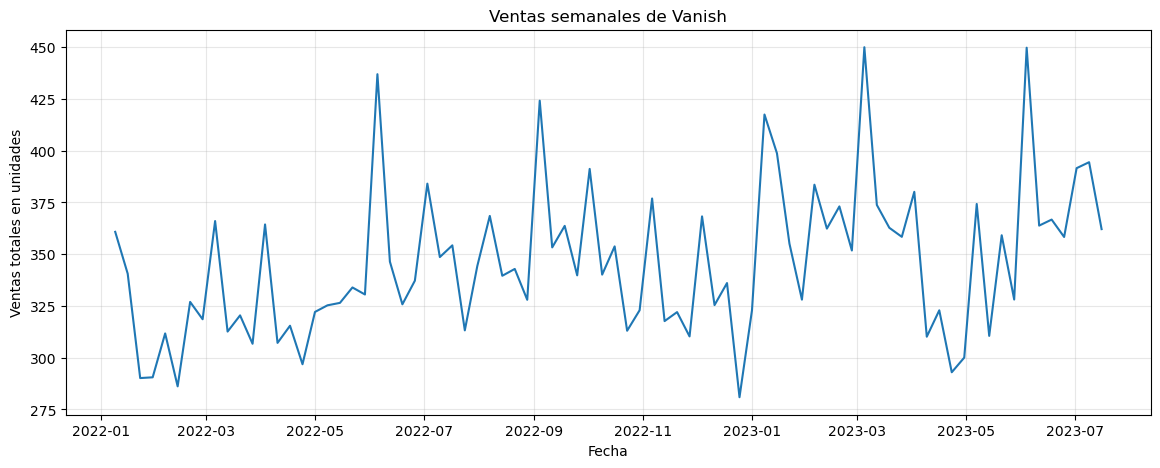

In [107]:
# 40. Visualizar la evolución semanal de las ventas de Vanish

plt.figure(figsize=(14, 5))

plt.plot(
    serie_modelo.index,
    serie_modelo['VANISH']
)

plt.title('Ventas semanales de Vanish')
plt.xlabel('Fecha')
plt.ylabel('Ventas totales en unidades')
plt.grid(alpha=0.3)

plt.show()

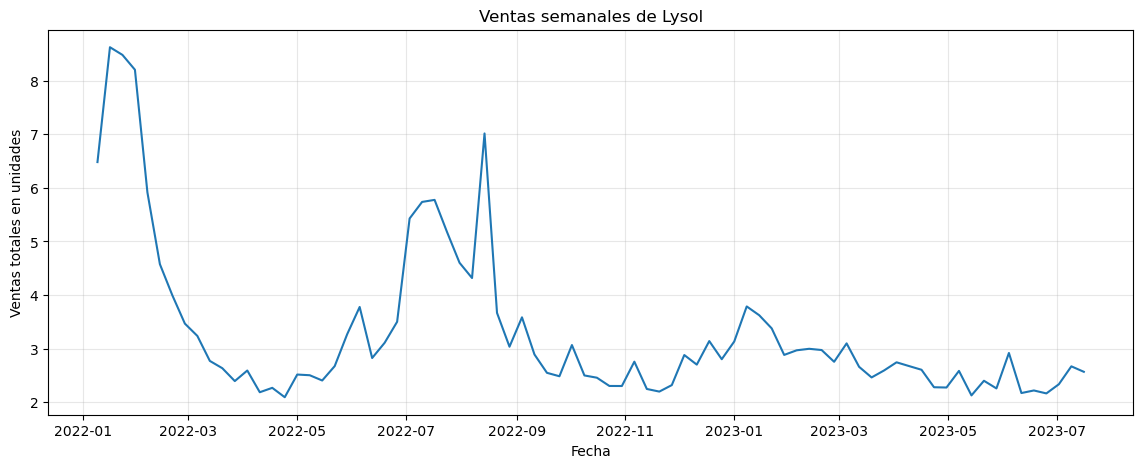

In [109]:
# 41. Visualizar la evolución semanal de las ventas de Lysol

plt.figure(figsize=(14, 5))

plt.plot(
    serie_modelo.index,
    serie_modelo['LYSOL']
)

plt.title('Ventas semanales de Lysol')
plt.xlabel('Fecha')
plt.ylabel('Ventas totales en unidades')
plt.grid(alpha=0.3)

plt.show()

In [111]:
# 42. Calcular medias móviles de 4 semanas

serie_modelo['VANISH_MA4'] = (
    serie_modelo['VANISH']
    .rolling(window=4)
    .mean()
)

serie_modelo['LYSOL_MA4'] = (
    serie_modelo['LYSOL']
    .rolling(window=4)
    .mean()
)

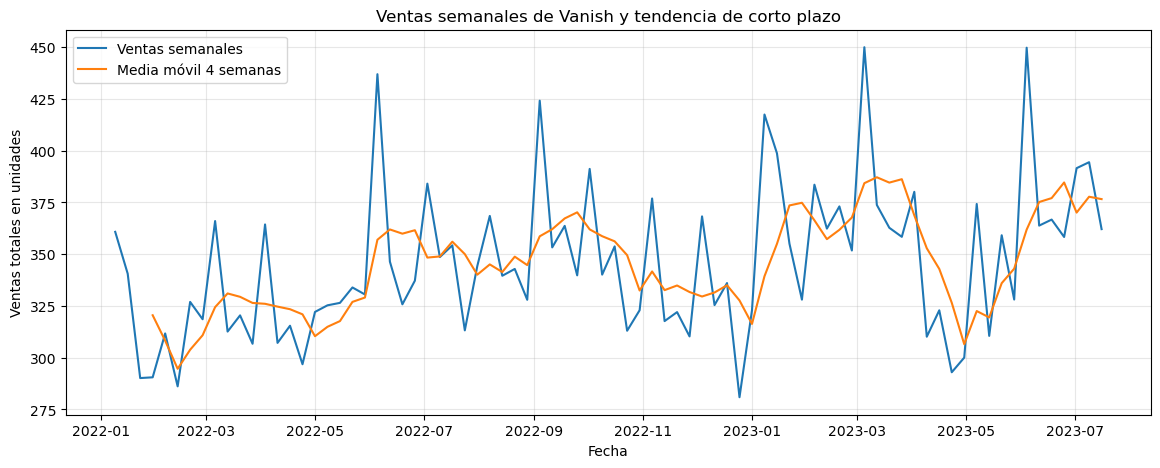

In [113]:
# 43. Comparar las ventas de Vanish con su media móvil de 4 semanas

plt.figure(figsize=(14, 5))

plt.plot(
    serie_modelo.index,
    serie_modelo['VANISH'],
    label='Ventas semanales'
)

plt.plot(
    serie_modelo.index,
    serie_modelo['VANISH_MA4'],
    label='Media móvil 4 semanas'
)

plt.title('Ventas semanales de Vanish y tendencia de corto plazo')
plt.xlabel('Fecha')
plt.ylabel('Ventas totales en unidades')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

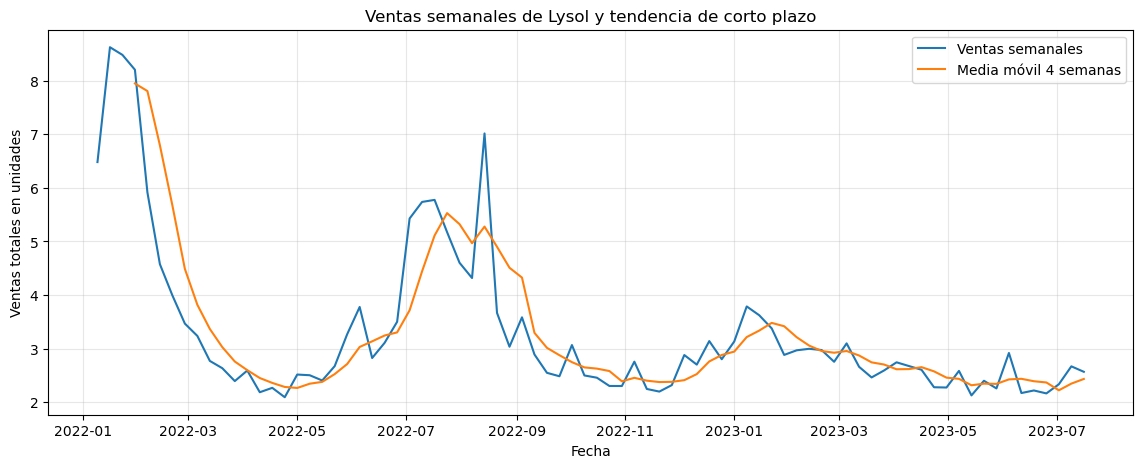

In [115]:
# 44. Comparar las ventas de Lysol con su media móvil de 4 semanas

plt.figure(figsize=(14, 5))

plt.plot(
    serie_modelo.index,
    serie_modelo['LYSOL'],
    label='Ventas semanales'
)

plt.plot(
    serie_modelo.index,
    serie_modelo['LYSOL_MA4'],
    label='Media móvil 4 semanas'
)

plt.title('Ventas semanales de Lysol y tendencia de corto plazo')
plt.xlabel('Fecha')
plt.ylabel('Ventas totales en unidades')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [117]:
# 45. Definir el tamaño de los conjuntos de entrenamiento y prueba

n_total = len(serie_modelo)
n_test = 16
n_train = n_total - n_test

print('Observaciones totales:', n_total)
print('Observaciones de entrenamiento:', n_train)
print('Observaciones de prueba:', n_test)

print('\nPorcentaje entrenamiento:',
      round(n_train / n_total * 100, 2), '%')

print('Porcentaje prueba:',
      round(n_test / n_total * 100, 2), '%')

Observaciones totales: 80
Observaciones de entrenamiento: 64
Observaciones de prueba: 16

Porcentaje entrenamiento: 80.0 %
Porcentaje prueba: 20.0 %


In [119]:
# 46. Dividir la serie de Vanish en entrenamiento y prueba

train_vanish = serie_modelo['VANISH'].iloc[:-n_test]
test_vanish = serie_modelo['VANISH'].iloc[-n_test:]

print('Training Vanish:')
print(train_vanish.index.min(), '→', train_vanish.index.max())
print('Observaciones:', len(train_vanish))

print('\nTesting Vanish:')
print(test_vanish.index.min(), '→', test_vanish.index.max())
print('Observaciones:', len(test_vanish))

Training Vanish:
2022-01-09 00:00:00 → 2023-03-26 00:00:00
Observaciones: 64

Testing Vanish:
2023-04-02 00:00:00 → 2023-07-16 00:00:00
Observaciones: 16


In [121]:
# 47. Dividir la serie de Lysol en entrenamiento y prueba

train_lysol = serie_modelo['LYSOL'].iloc[:-n_test]
test_lysol = serie_modelo['LYSOL'].iloc[-n_test:]

print('Training Lysol:')
print(train_lysol.index.min(), '→', train_lysol.index.max())
print('Observaciones:', len(train_lysol))

print('\nTesting Lysol:')
print(test_lysol.index.min(), '→', test_lysol.index.max())
print('Observaciones:', len(test_lysol))

Training Lysol:
2022-01-09 00:00:00 → 2023-03-26 00:00:00
Observaciones: 64

Testing Lysol:
2023-04-02 00:00:00 → 2023-07-16 00:00:00
Observaciones: 16


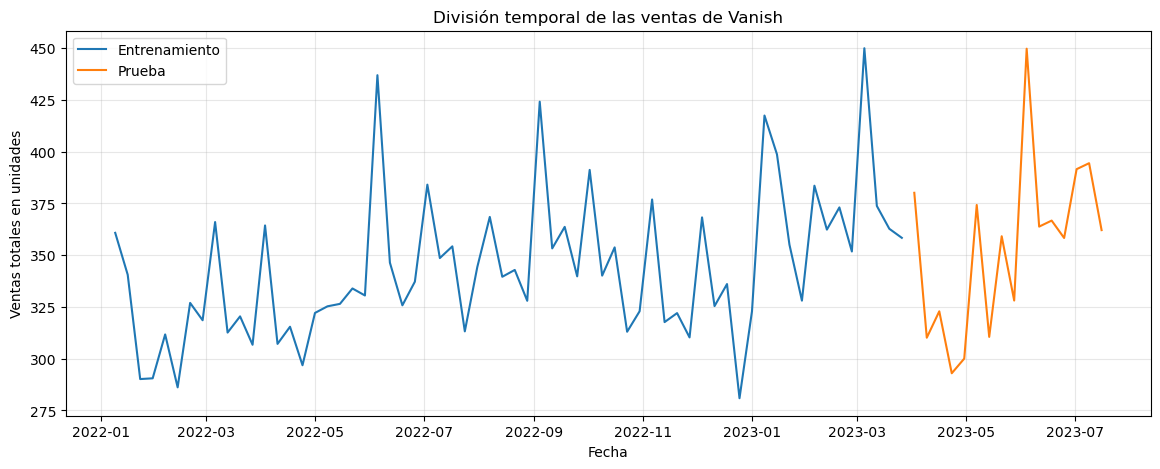

In [123]:
# 48. Visualizar la división temporal de Vanish

plt.figure(figsize=(14, 5))

plt.plot(
    train_vanish.index,
    train_vanish,
    label='Entrenamiento'
)

plt.plot(
    test_vanish.index,
    test_vanish,
    label='Prueba'
)

plt.title('División temporal de las ventas de Vanish')
plt.xlabel('Fecha')
plt.ylabel('Ventas totales en unidades')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

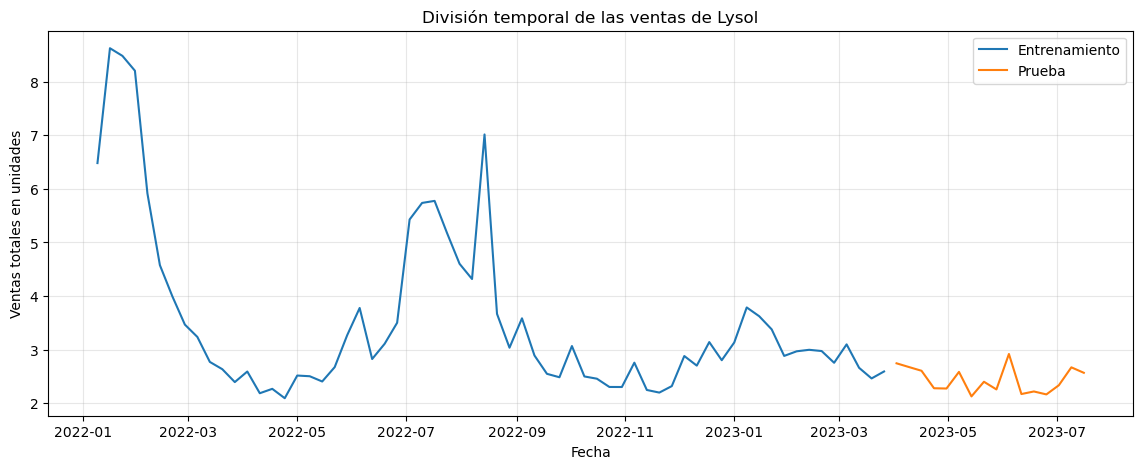

In [125]:
# 49. Visualizar la división temporal de Lysol

plt.figure(figsize=(14, 5))

plt.plot(
    train_lysol.index,
    train_lysol,
    label='Entrenamiento'
)

plt.plot(
    test_lysol.index,
    test_lysol,
    label='Prueba'
)

plt.title('División temporal de las ventas de Lysol')
plt.xlabel('Fecha')
plt.ylabel('Ventas totales en unidades')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [127]:
# 50. Importar la prueba de Dickey-Fuller aumentada para evaluar estacionariedad

from statsmodels.tsa.stattools import adfuller

In [139]:
# 51. Crear una función para evaluar la estacionariedad de una serie temporal

def prueba_adf(serie, nombre):
    
    resultado = adfuller(serie.dropna())
    
    print(f'Prueba ADF - {nombre}')
    print('-' * 40)
    print(f'Estadístico ADF: {resultado[0]:.4f}')
    print(f'p-value: {resultado[1]:.6f}')
    
    print('\nValores críticos:')
    
    for nivel, valor in resultado[4].items():
        print(f'{nivel}: {valor:.4f}')
    
    if resultado[1] < 0.05:
        print('\nConclusión: Se rechaza H0. La serie puede considerarse estacionaria.')
    else:
        print('\nConclusión: No se rechaza H0. No hay evidencia suficiente para considerar la serie estacionaria.')

In [141]:
# 52. Evaluar la estacionariedad de las ventas de Vanish

prueba_adf(
    train_vanish,
    'Vanish'
)

Prueba ADF - Vanish
----------------------------------------
Estadístico ADF: -1.6173
p-value: 0.474147

Valores críticos:
1%: -3.5577
5%: -2.9168
10%: -2.5962

Conclusión: No se rechaza H0. No hay evidencia suficiente para considerar la serie estacionaria.


In [143]:
# 53. Evaluar la estacionariedad de las ventas de Lysol

prueba_adf(
    train_lysol,
    'Lysol'
)

Prueba ADF - Lysol
----------------------------------------
Estadístico ADF: -2.5773
p-value: 0.097772

Valores críticos:
1%: -3.5387
5%: -2.9086
10%: -2.5919

Conclusión: No se rechaza H0. No hay evidencia suficiente para considerar la serie estacionaria.


In [145]:
# 54. Aplicar una primera diferencia a las series de entrenamiento

train_vanish_diff = train_vanish.diff().dropna()
train_lysol_diff = train_lysol.diff().dropna()

print('Observaciones Vanish diferenciadas:', len(train_vanish_diff))
print('Observaciones Lysol diferenciadas:', len(train_lysol_diff))

Observaciones Vanish diferenciadas: 63
Observaciones Lysol diferenciadas: 63


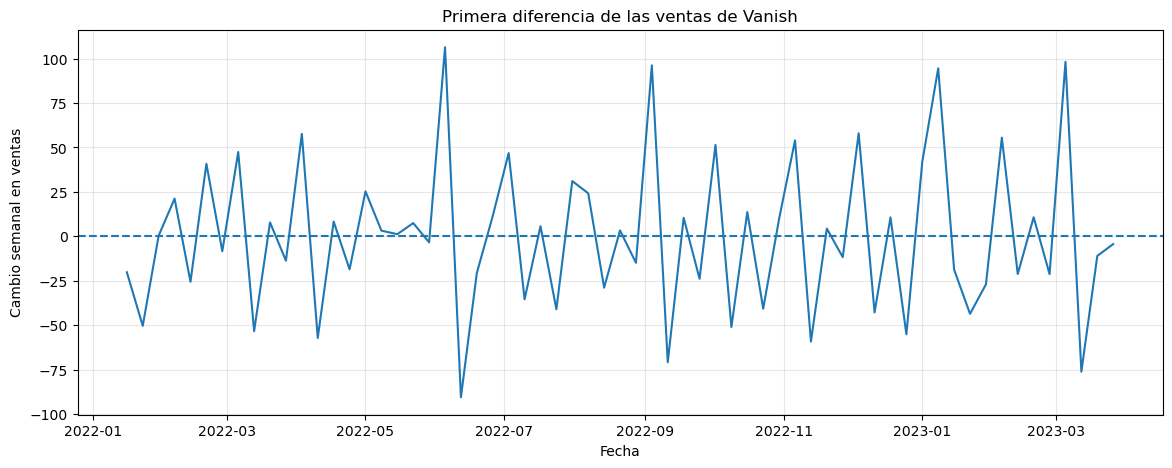

In [147]:
# 55. Visualizar la primera diferencia de las ventas de Vanish

plt.figure(figsize=(14, 5))

plt.plot(
    train_vanish_diff.index,
    train_vanish_diff
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.title('Primera diferencia de las ventas de Vanish')
plt.xlabel('Fecha')
plt.ylabel('Cambio semanal en ventas')
plt.grid(alpha=0.3)

plt.show()

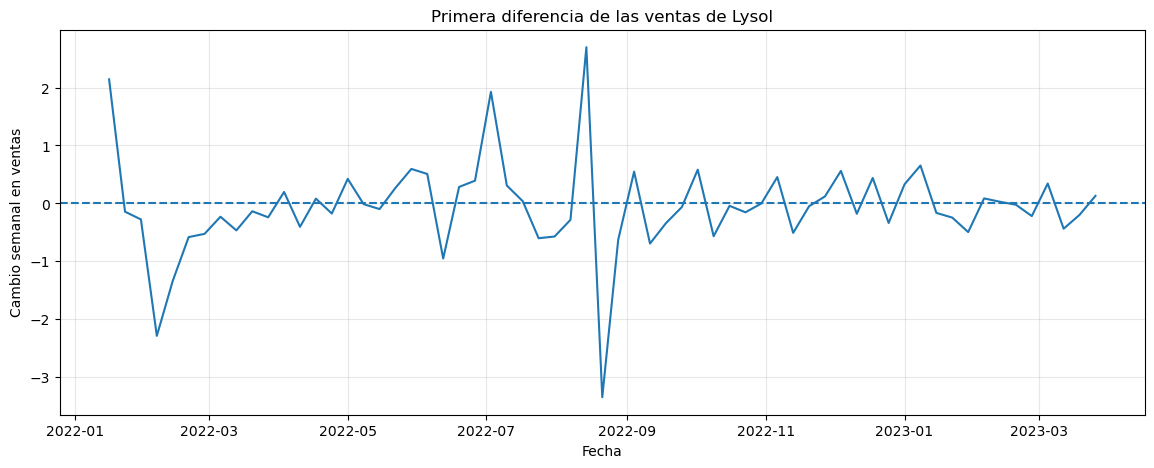

In [149]:
# 56. Visualizar la primera diferencia de las ventas de Lysol

plt.figure(figsize=(14, 5))

plt.plot(
    train_lysol_diff.index,
    train_lysol_diff
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.title('Primera diferencia de las ventas de Lysol')
plt.xlabel('Fecha')
plt.ylabel('Cambio semanal en ventas')
plt.grid(alpha=0.3)

plt.show()

In [151]:
# 57. Evaluar la estacionariedad después de aplicar una primera diferencia

prueba_adf(
    train_vanish_diff,
    'Vanish - Primera diferencia'
)

print('\n')

prueba_adf(
    train_lysol_diff,
    'Lysol - Primera diferencia'
)

Prueba ADF - Vanish - Primera diferencia
----------------------------------------
Estadístico ADF: -3.5874
p-value: 0.006006

Valores críticos:
1%: -3.5656
5%: -2.9201
10%: -2.5980

Conclusión: Se rechaza H0. La serie puede considerarse estacionaria.


Prueba ADF - Lysol - Primera diferencia
----------------------------------------
Estadístico ADF: -6.0571
p-value: 0.000000

Valores críticos:
1%: -3.5424
5%: -2.9102
10%: -2.5927

Conclusión: Se rechaza H0. La serie puede considerarse estacionaria.


In [153]:
# 58. Importar las funciones ACF y PACF para analizar la autocorrelación

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

<Figure size 1200x500 with 0 Axes>

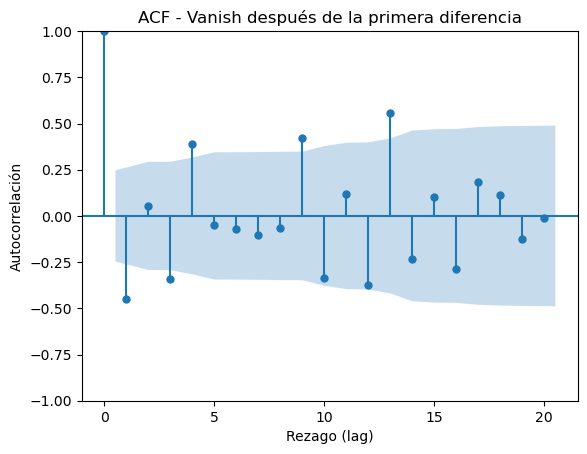

In [155]:
# 59. Analizar la autocorrelación de la serie diferenciada de Vanish

plt.figure(figsize=(12, 5))

plot_acf(
    train_vanish_diff,
    lags=20
)

plt.title('ACF - Vanish después de la primera diferencia')
plt.xlabel('Rezago (lag)')
plt.ylabel('Autocorrelación')

plt.show()

<Figure size 1200x500 with 0 Axes>

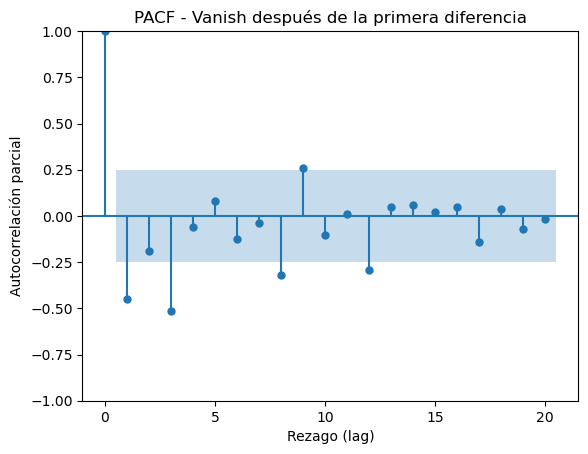

In [157]:
# 60. Analizar la autocorrelación parcial de la serie diferenciada de Vanish

plt.figure(figsize=(12, 5))

plot_pacf(
    train_vanish_diff,
    lags=20,
    method='ywm'
)

plt.title('PACF - Vanish después de la primera diferencia')
plt.xlabel('Rezago (lag)')
plt.ylabel('Autocorrelación parcial')

plt.show()

<Figure size 1200x500 with 0 Axes>

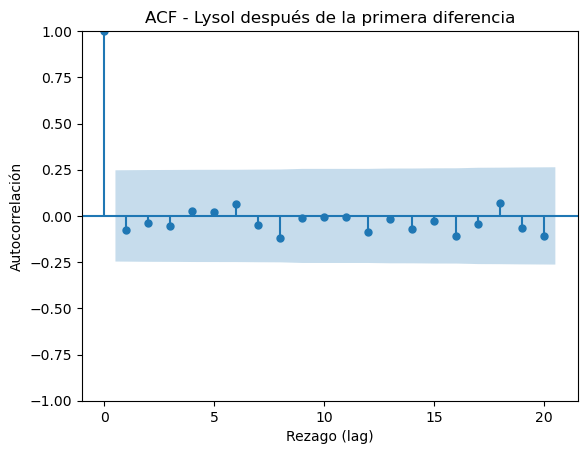

In [159]:
# 61. Analizar la autocorrelación de la serie diferenciada de Lysol

plt.figure(figsize=(12, 5))

plot_acf(
    train_lysol_diff,
    lags=20
)

plt.title('ACF - Lysol después de la primera diferencia')
plt.xlabel('Rezago (lag)')
plt.ylabel('Autocorrelación')

plt.show()

<Figure size 1200x500 with 0 Axes>

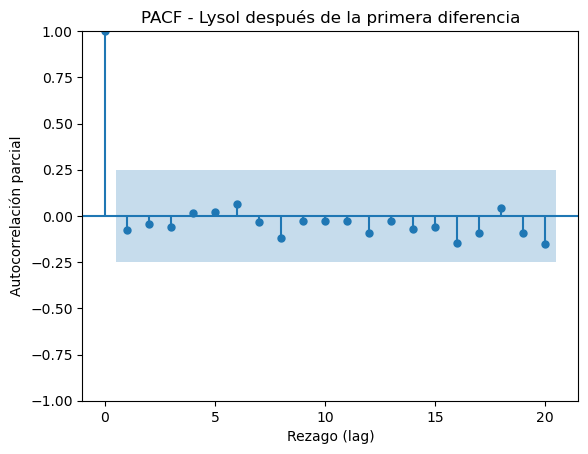

In [161]:
# 62. Analizar la autocorrelación parcial de la serie diferenciada de Lysol

plt.figure(figsize=(12, 5))

plot_pacf(
    train_lysol_diff,
    lags=20,
    method='ywm'
)

plt.title('PACF - Lysol después de la primera diferencia')
plt.xlabel('Rezago (lag)')
plt.ylabel('Autocorrelación parcial')

plt.show()

In [163]:
# 63. Importar el modelo ARIMA

from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings('ignore')

In [165]:
# 64. Crear una función para comparar modelos ARIMA mediante AIC y BIC

def buscar_arima(serie, nombre, max_p=3, max_q=3):
    
    resultados = []
    
    for p in range(max_p + 1):
        for q in range(max_q + 1):
            
            try:
                modelo = ARIMA(
                    serie,
                    order=(p, 1, q)
                )
                
                ajuste = modelo.fit()
                
                resultados.append({
                    'Marca': nombre,
                    'p': p,
                    'd': 1,
                    'q': q,
                    'AIC': ajuste.aic,
                    'BIC': ajuste.bic
                })
                
            except:
                pass
    
    resultados_df = pd.DataFrame(resultados)
    
    return resultados_df.sort_values('AIC').reset_index(drop=True)

In [167]:
# 65. Evaluar diferentes combinaciones ARIMA para Vanish

resultados_vanish = buscar_arima(
    train_vanish,
    'Vanish'
)

resultados_vanish.head(10)

,Marca,p,d,q,AIC,BIC
0,Vanish,3,1,0,620.930888,629.503426
1,Vanish,2,1,3,622.319008,635.177817
2,Vanish,3,1,1,622.418807,633.134481
3,Vanish,3,1,2,624.418670,637.277479
4,Vanish,3,1,3,625.527006,640.528949
5,Vanish,0,1,1,626.797545,631.083815
6,Vanish,1,1,3,627.155733,637.871407
7,Vanish,0,1,2,628.640831,635.070235
8,Vanish,1,1,1,628.647846,635.077250
9,Vanish,1,1,2,630.540647,639.113186


In [169]:
# 66. Evaluar diferentes combinaciones ARIMA para Lysol

resultados_lysol = buscar_arima(
    train_lysol,
    'Lysol'
)

resultados_lysol.head(10)

,Marca,p,d,q,AIC,BIC
0,Lysol,0,1,0,155.801315,157.944450
1,Lysol,0,1,1,157.478228,161.764497
2,Lysol,1,1,0,157.504227,161.790496
3,Lysol,1,1,1,159.386770,165.816174
4,Lysol,0,1,2,159.394030,165.823434
5,Lysol,2,1,0,159.418022,165.847427
6,Lysol,2,1,2,160.344641,171.060315
7,Lysol,3,1,0,161.244675,169.817214
8,Lysol,0,1,3,161.312363,169.884902
9,Lysol,2,1,1,161.370474,169.943012


In [171]:
# 67. Entrenar el modelo ARIMA seleccionado para Vanish

modelo_vanish = ARIMA(
    train_vanish,
    order=(3, 1, 0)
)

ajuste_vanish = modelo_vanish.fit()

print('Modelo Vanish: ARIMA(3,1,0)')
print('AIC:', ajuste_vanish.aic)
print('BIC:', ajuste_vanish.bic)

Modelo Vanish: ARIMA(3,1,0)
AIC: 620.9308875063089
BIC: 629.503426411875


In [173]:
# 68. Entrenar el modelo ARIMA seleccionado para Lysol

modelo_lysol = ARIMA(
    train_lysol,
    order=(0, 1, 0)
)

ajuste_lysol = modelo_lysol.fit()

print('Modelo Lysol: ARIMA(0,1,0)')
print('AIC:', ajuste_lysol.aic)
print('BIC:', ajuste_lysol.bic)

Modelo Lysol: ARIMA(0,1,0)
AIC: 155.8013147915948
BIC: 157.94444951798633


In [175]:
# 69. Mostrar el resumen estadístico del modelo de Vanish

print(ajuste_vanish.summary())

                               SARIMAX Results                                
Dep. Variable:                 VANISH   No. Observations:                   64
Model:                 ARIMA(3, 1, 0)   Log Likelihood                -306.465
Date:                Sun, 27 Sep 2026   AIC                            620.931
Time:                        18:43:51   BIC                            629.503
Sample:                    01-09-2022   HQIC                           624.303
                         - 03-26-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6669      0.145     -4.604      0.000      -0.951      -0.383
ar.L2         -0.5387      0.164     -3.291      0.001      -0.860      -0.218
ar.L3         -0.5817      0.164     -3.548      0.0

In [177]:
# 70. Mostrar el resumen estadístico del modelo de Lysol

print(ajuste_lysol.summary())

                               SARIMAX Results                                
Dep. Variable:                  LYSOL   No. Observations:                   64
Model:                 ARIMA(0, 1, 0)   Log Likelihood                 -76.901
Date:                Sun, 27 Sep 2026   AIC                            155.801
Time:                        18:44:40   BIC                            157.944
Sample:                    01-09-2022   HQIC                           156.644
                         - 03-26-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.6726      0.061     10.975      0.000       0.552       0.793
Ljung-Box (L1) (Q):                   0.37   Jarque-Bera (JB):                84.01
Prob(Q):                              0.54   Pr

In [179]:
# 71. Evaluar autocorrelación restante en los residuos con Ljung-Box

from statsmodels.stats.diagnostic import acorr_ljungbox

residuos_vanish = ajuste_vanish.resid.iloc[1:].dropna()
residuos_lysol = ajuste_lysol.resid.iloc[1:].dropna()

ljung_vanish = acorr_ljungbox(
    residuos_vanish,
    lags=[10],
    model_df=3,
    return_df=True
)

ljung_lysol = acorr_ljungbox(
    residuos_lysol,
    lags=[10],
    model_df=0,
    return_df=True
)

print('Ljung-Box - Vanish')
print(ljung_vanish)

print('\nLjung-Box - Lysol')
print(ljung_lysol)

Ljung-Box - Vanish
     lb_stat  lb_pvalue
10  8.923518   0.258194

Ljung-Box - Lysol
     lb_stat  lb_pvalue
10  2.267001   0.993854


In [181]:
# 72. Generar predicciones de Vanish para las 16 semanas del conjunto de prueba

pred_vanish = ajuste_vanish.forecast(
    steps=len(test_vanish)
)

pred_vanish.index = test_vanish.index

pred_vanish.head()

Date
2023-04-02    411.566974
2023-04-09    384.876935
2023-04-16    376.574718
2023-04-23    365.563143
2023-04-30    392.903826
Freq: 7D, Name: predicted_mean, dtype: float64

In [183]:
# 73. Generar predicciones de Lysol para las 16 semanas del conjunto de prueba

pred_lysol = ajuste_lysol.forecast(
    steps=len(test_lysol)
)

pred_lysol.index = test_lysol.index

pred_lysol.head()

Date
2023-04-02    2.593
2023-04-09    2.593
2023-04-16    2.593
2023-04-23    2.593
2023-04-30    2.593
Freq: 7D, Name: predicted_mean, dtype: float64

In [185]:
# 74. Importar las métricas necesarias para evaluar los modelos

from sklearn.metrics import mean_squared_error, mean_absolute_error

In [187]:
# 75. Crear una función para calcular las métricas de error

def evaluar_modelo(real, predicho, nombre):
    
    mse = mean_squared_error(real, predicho)
    mae = mean_absolute_error(real, predicho)
    
    if (real == 0).any():
        mape = np.nan
    else:
        mape = np.mean(
            np.abs((real - predicho) / real)
        ) * 100
    
    print(f'Evaluación del modelo - {nombre}')
    print('-' * 40)
    print(f'MSE:  {mse:.4f}')
    print(f'MAE:  {mae:.4f}')
    
    if np.isnan(mape):
        print('MAPE: No calculable porque existen valores reales iguales a 0.')
    else:
        print(f'MAPE: {mape:.2f}%')

In [189]:
# 76. Evaluar las predicciones del modelo de Vanish

evaluar_modelo(
    test_vanish,
    pred_vanish,
    'Vanish - ARIMA(3,1,0)'
)

Evaluación del modelo - Vanish - ARIMA(3,1,0)
----------------------------------------
MSE:  2370.3238
MAE:  39.7330
MAPE: 11.96%


In [191]:
# 77. Evaluar las predicciones del modelo de Lysol

evaluar_modelo(
    test_lysol,
    pred_lysol,
    'Lysol - ARIMA(0,1,0)'
)

Evaluación del modelo - Lysol - ARIMA(0,1,0)
----------------------------------------
MSE:  0.0796
MAE:  0.2366
MAPE: 10.24%


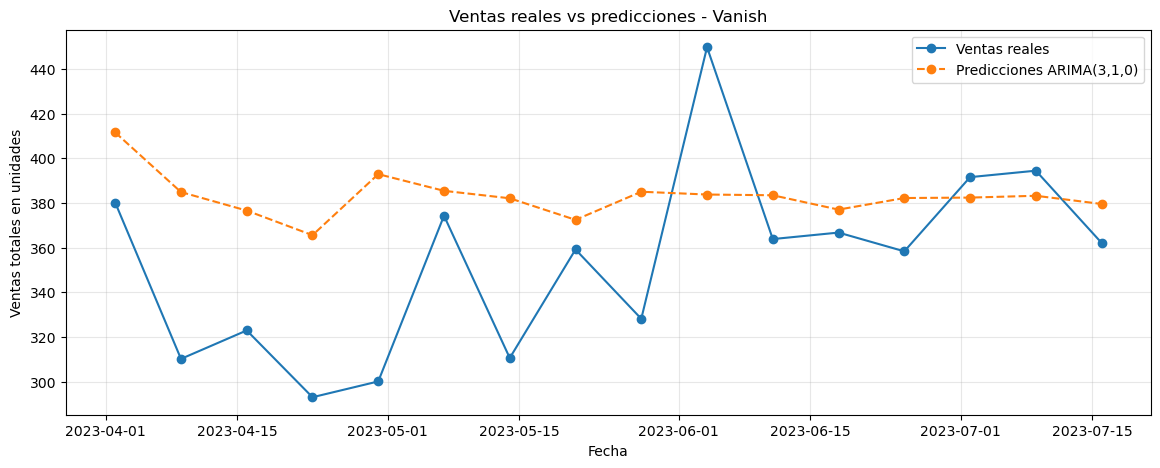

In [193]:
# 78. Comparar las ventas reales y las predicciones de Vanish

plt.figure(figsize=(14, 5))

plt.plot(
    test_vanish.index,
    test_vanish,
    marker='o',
    label='Ventas reales'
)

plt.plot(
    pred_vanish.index,
    pred_vanish,
    marker='o',
    linestyle='--',
    label='Predicciones ARIMA(3,1,0)'
)

plt.title('Ventas reales vs predicciones - Vanish')
plt.xlabel('Fecha')
plt.ylabel('Ventas totales en unidades')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

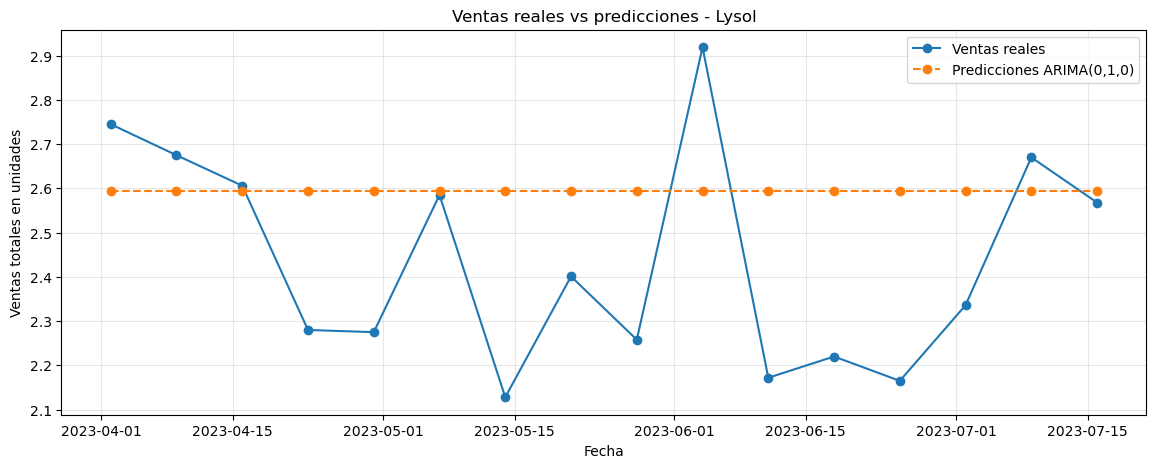

In [195]:
# 79. Comparar las ventas reales y las predicciones de Lysol

plt.figure(figsize=(14, 5))

plt.plot(
    test_lysol.index,
    test_lysol,
    marker='o',
    label='Ventas reales'
)

plt.plot(
    pred_lysol.index,
    pred_lysol,
    marker='o',
    linestyle='--',
    label='Predicciones ARIMA(0,1,0)'
)

plt.title('Ventas reales vs predicciones - Lysol')
plt.xlabel('Fecha')
plt.ylabel('Ventas totales en unidades')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [197]:
# 80. Crear conjuntos internos de entrenamiento y validación para optimizar los modelos

n_validacion = 12

subtrain_vanish = train_vanish.iloc[:-n_validacion]
validacion_vanish = train_vanish.iloc[-n_validacion:]

subtrain_lysol = train_lysol.iloc[:-n_validacion]
validacion_lysol = train_lysol.iloc[-n_validacion:]

print('VANISH')
print('Subentrenamiento:', len(subtrain_vanish))
print('Validación:', len(validacion_vanish))

print('\nLYSOL')
print('Subentrenamiento:', len(subtrain_lysol))
print('Validación:', len(validacion_lysol))

VANISH
Subentrenamiento: 52
Validación: 12

LYSOL
Subentrenamiento: 52
Validación: 12


In [199]:
# 81. Verificar los periodos temporales del subentrenamiento y validación

print('VANISH')
print(
    'Subentrenamiento:',
    subtrain_vanish.index.min(),
    '→',
    subtrain_vanish.index.max()
)
print(
    'Validación:',
    validacion_vanish.index.min(),
    '→',
    validacion_vanish.index.max()
)

print('\nLYSOL')
print(
    'Subentrenamiento:',
    subtrain_lysol.index.min(),
    '→',
    subtrain_lysol.index.max()
)
print(
    'Validación:',
    validacion_lysol.index.min(),
    '→',
    validacion_lysol.index.max()
)

VANISH
Subentrenamiento: 2022-01-09 00:00:00 → 2023-01-01 00:00:00
Validación: 2023-01-08 00:00:00 → 2023-03-26 00:00:00

LYSOL
Subentrenamiento: 2022-01-09 00:00:00 → 2023-01-01 00:00:00
Validación: 2023-01-08 00:00:00 → 2023-03-26 00:00:00


In [201]:
# 82. Crear una función para optimizar ARIMA mediante validación temporal

def buscar_arima_validacion(
    subtrain,
    validacion,
    nombre,
    max_p=3,
    max_q=3
):
    
    resultados = []
    errores = []
    
    for p in range(max_p + 1):
        for q in range(max_q + 1):
            
            try:
                with warnings.catch_warnings():
                    warnings.simplefilter('ignore')
                    
                    modelo = ARIMA(
                        subtrain,
                        order=(p, 1, q)
                    )
                    
                    ajuste = modelo.fit()
                
                prediccion = ajuste.forecast(
                    steps=len(validacion)
                )
                
                prediccion.index = validacion.index
                
                mse = mean_squared_error(
                    validacion,
                    prediccion
                )
                
                mae = mean_absolute_error(
                    validacion,
                    prediccion
                )
                
                mape = np.mean(
                    np.abs(
                        (validacion - prediccion)
                        / validacion
                    )
                ) * 100
                
                resultados.append({
                    'Marca': nombre,
                    'p': p,
                    'd': 1,
                    'q': q,
                    'MSE': mse,
                    'MAE': mae,
                    'MAPE': mape,
                    'AIC': ajuste.aic,
                    'BIC': ajuste.bic
                })
                
            except Exception as e:
                errores.append(
                    f'ARIMA({p},1,{q}): {e}'
                )
    
    resultados_df = pd.DataFrame(resultados)
    
    resultados_df = resultados_df.sort_values(
        by=['MAPE', 'MAE']
    ).reset_index(drop=True)
    
    return resultados_df, errores

In [203]:
# 83. Evaluar configuraciones ARIMA para Vanish mediante validación temporal

optimizacion_vanish, errores_vanish = buscar_arima_validacion(
    subtrain_vanish,
    validacion_vanish,
    'Vanish'
)

optimizacion_vanish.head(10)

,Marca,p,d,q,MSE,MAE,MAPE,AIC,BIC
0,Vanish,2,1,3,2652.445271,41.942191,10.610888,500.680955,512.271909
1,Vanish,1,1,3,3005.605637,44.828194,11.363499,501.059236,510.718364
2,Vanish,0,1,1,3336.226518,48.531309,12.327814,500.014476,503.878127
3,Vanish,2,1,2,3418.439032,48.973853,12.439885,504.025219,513.684347
4,Vanish,2,1,1,3440.897281,49.546137,12.597553,503.907831,511.635134
5,Vanish,1,1,1,3462.566854,49.828376,12.675211,501.919509,507.714986
6,Vanish,0,1,2,3467.122559,49.884040,12.690442,501.919920,507.715397
7,Vanish,0,1,3,3495.538239,50.210417,12.779222,503.914916,511.642218
8,Vanish,1,1,2,3679.676922,51.482300,13.101968,502.773910,510.501213
9,Vanish,0,1,0,3827.463367,53.352833,13.617615,525.424321,527.356147


In [205]:
# 84. Evaluar configuraciones ARIMA para Lysol mediante validación temporal

optimizacion_lysol, errores_lysol = buscar_arima_validacion(
    subtrain_lysol,
    validacion_lysol,
    'Lysol'
)

optimizacion_lysol.head(10)

,Marca,p,d,q,MSE,MAE,MAPE,AIC,BIC
0,Lysol,3,1,0,0.154389,0.328259,11.065120,141.391582,149.118885
1,Lysol,0,1,3,0.154040,0.328109,11.065518,141.445191,149.172494
2,Lysol,3,1,1,0.155811,0.329722,11.102188,143.324718,152.983846
3,Lysol,1,1,1,0.156321,0.332855,11.254838,139.506988,145.302465
4,Lysol,1,1,2,0.156499,0.333446,11.278331,141.504760,149.232062
5,Lysol,2,1,1,0.156586,0.333710,11.288770,141.503820,149.231123
6,Lysol,0,1,2,0.157658,0.335796,11.366262,139.518242,145.313719
7,Lysol,0,1,1,0.158803,0.337025,11.405594,137.555782,141.419434
8,Lysol,2,1,0,0.158459,0.337421,11.427484,139.534927,145.330403
9,Lysol,1,1,0,0.159266,0.337889,11.437900,137.572865,141.436517


In [207]:
# 85. Consultar el desempeño en validación de los modelos originales

print('Modelo original Vanish - ARIMA(3,1,0)')
print(
    optimizacion_vanish[
        (optimizacion_vanish['p'] == 3) &
        (optimizacion_vanish['q'] == 0)
    ]
)

print('\nModelo original Lysol - ARIMA(0,1,0)')
print(
    optimizacion_lysol[
        (optimizacion_lysol['p'] == 0) &
        (optimizacion_lysol['q'] == 0)
    ]
)

Modelo original Vanish - ARIMA(3,1,0)
     Marca  p  d  q          MSE        MAE       MAPE         AIC         BIC
11  Vanish  3  1  0  4672.158367  60.699734  15.598808  495.713191  503.440494

Modelo original Lysol - ARIMA(0,1,0)
    Marca  p  d  q       MSE       MAE       MAPE         AIC        BIC
10  Lysol  0  1  0  0.164034  0.349417  11.895205  135.840945  137.77277


In [209]:
# 86. Entrenar los modelos optimizados con todo el conjunto de entrenamiento

modelo_vanish_opt = ARIMA(
    train_vanish,
    order=(2, 1, 3)
)

ajuste_vanish_opt = modelo_vanish_opt.fit()


modelo_lysol_opt = ARIMA(
    train_lysol,
    order=(3, 1, 0)
)

ajuste_lysol_opt = modelo_lysol_opt.fit()

print('Modelo optimizado Vanish: ARIMA(2,1,3)')
print('AIC:', ajuste_vanish_opt.aic)
print('BIC:', ajuste_vanish_opt.bic)

print('\nModelo optimizado Lysol: ARIMA(3,1,0)')
print('AIC:', ajuste_lysol_opt.aic)
print('BIC:', ajuste_lysol_opt.bic)

Modelo optimizado Vanish: ARIMA(2,1,3)
AIC: 622.3190084156519
BIC: 635.177816774001

Modelo optimizado Lysol: ARIMA(3,1,0)
AIC: 161.24467535024996
BIC: 169.81721425581608


In [211]:
# 87. Generar predicciones finales con los modelos optimizados

pred_vanish_opt = ajuste_vanish_opt.forecast(
    steps=len(test_vanish)
)

pred_vanish_opt.index = test_vanish.index


pred_lysol_opt = ajuste_lysol_opt.forecast(
    steps=len(test_lysol)
)

pred_lysol_opt.index = test_lysol.index

In [213]:
# 88. Evaluar los modelos optimizados sobre el conjunto de prueba final

evaluar_modelo(
    test_vanish,
    pred_vanish_opt,
    'Vanish optimizado - ARIMA(2,1,3)'
)

print('\n')

evaluar_modelo(
    test_lysol,
    pred_lysol_opt,
    'Lysol optimizado - ARIMA(3,1,0)'
)

Evaluación del modelo - Vanish optimizado - ARIMA(2,1,3)
----------------------------------------
MSE:  1714.1246
MAE:  31.8744
MAPE: 9.46%


Evaluación del modelo - Lysol optimizado - ARIMA(3,1,0)
----------------------------------------
MSE:  0.0851
MAE:  0.2428
MAPE: 10.55%


In [215]:
# 89. Comparar las métricas del modelo original y optimizado

def obtener_metricas(real, predicho):
    
    mse = mean_squared_error(real, predicho)
    mae = mean_absolute_error(real, predicho)
    
    mape = np.mean(
        np.abs((real - predicho) / real)
    ) * 100
    
    return mse, mae, mape


mse_v_orig, mae_v_orig, mape_v_orig = obtener_metricas(
    test_vanish,
    pred_vanish
)

mse_v_opt, mae_v_opt, mape_v_opt = obtener_metricas(
    test_vanish,
    pred_vanish_opt
)


mse_l_orig, mae_l_orig, mape_l_orig = obtener_metricas(
    test_lysol,
    pred_lysol
)

mse_l_opt, mae_l_opt, mape_l_opt = obtener_metricas(
    test_lysol,
    pred_lysol_opt
)


comparacion_modelos = pd.DataFrame({
    'Marca': [
        'Vanish', 'Vanish',
        'Lysol', 'Lysol'
    ],
    'Modelo': [
        'Original ARIMA(3,1,0)',
        'Optimizado ARIMA(2,1,3)',
        'Original ARIMA(0,1,0)',
        'Optimizado ARIMA(3,1,0)'
    ],
    'MSE': [
        mse_v_orig, mse_v_opt,
        mse_l_orig, mse_l_opt
    ],
    'MAE': [
        mae_v_orig, mae_v_opt,
        mae_l_orig, mae_l_opt
    ],
    'MAPE': [
        mape_v_orig, mape_v_opt,
        mape_l_orig, mape_l_opt
    ]
})

comparacion_modelos

,Marca,Modelo,MSE,MAE,MAPE
0,Vanish,"Original ARIMA(3,1,0)",2370.323795,39.733006,11.955581
1,Vanish,"Optimizado ARIMA(2,1,3)",1714.124553,31.874402,9.460387
2,Lysol,"Original ARIMA(0,1,0)",0.079556,0.236562,10.236421
3,Lysol,"Optimizado ARIMA(3,1,0)",0.085091,0.242776,10.545698


In [217]:
# 90. Reentrenar los modelos finales utilizando las 80 semanas históricas disponibles

modelo_final_vanish = ARIMA(
    serie_modelo['VANISH'],
    order=(2, 1, 3)
)

ajuste_final_vanish = modelo_final_vanish.fit()


modelo_final_lysol = ARIMA(
    serie_modelo['LYSOL'],
    order=(0, 1, 0)
)

ajuste_final_lysol = modelo_final_lysol.fit()

print('Modelo final Vanish: ARIMA(2,1,3)')
print('AIC:', ajuste_final_vanish.aic)
print('BIC:', ajuste_final_vanish.bic)

print('\nModelo final Lysol: ARIMA(0,1,0)')
print('AIC:', ajuste_final_lysol.aic)
print('BIC:', ajuste_final_lysol.bic)

Modelo final Vanish: ARIMA(2,1,3)
AIC: 786.402766697818
BIC: 800.6194538126201

Modelo final Lysol: ARIMA(0,1,0)
AIC: 180.073545058078
BIC: 182.44299291054503


In [219]:
# 91. Generar pronósticos para las próximas 12 semanas

n_futuro = 12

forecast_vanish = ajuste_final_vanish.get_forecast(
    steps=n_futuro
)

forecast_lysol = ajuste_final_lysol.get_forecast(
    steps=n_futuro
)

pred_futuro_vanish = forecast_vanish.predicted_mean
pred_futuro_lysol = forecast_lysol.predicted_mean

In [221]:
# 92. Obtener intervalos de confianza del 95 % para las predicciones

ic_vanish = forecast_vanish.conf_int(alpha=0.05)
ic_lysol = forecast_lysol.conf_int(alpha=0.05)

print('Periodo pronosticado:')
print(pred_futuro_vanish.index.min(), '→', pred_futuro_vanish.index.max())

Periodo pronosticado:
2023-07-23 00:00:00 → 2023-10-08 00:00:00


In [223]:
# 93. Crear una tabla comparativa con las predicciones futuras

tabla_pronostico = pd.DataFrame({
    'Vanish_Prediccion': pred_futuro_vanish,
    'Vanish_Limite_Inferior': ic_vanish.iloc[:, 0],
    'Vanish_Limite_Superior': ic_vanish.iloc[:, 1],
    'Lysol_Prediccion': pred_futuro_lysol,
    'Lysol_Limite_Inferior': ic_lysol.iloc[:, 0],
    'Lysol_Limite_Superior': ic_lysol.iloc[:, 1]
})

tabla_pronostico.index.name = 'Fecha'

tabla_pronostico.round(3)

,Vanish_Prediccion,Vanish_Limite_Inferior,Vanish_Limite_Superior,Lysol_Prediccion,Lysol_Limite_Inferior,Lysol_Limite_Superior
Fecha,,,,,,
2023-07-23,378.612,316.646,440.578,2.568,1.104,4.032
2023-07-30,339.167,274.451,403.883,2.568,0.498,4.638
2023-08-06,394.806,329.141,460.471,2.568,0.033,5.103
2023-08-13,337.937,272.228,403.645,2.568,-0.360,5.496
2023-08-20,385.972,316.399,455.545,2.568,-0.705,5.841
2023-08-27,351.901,282.071,421.732,2.568,-1.018,6.154
2023-09-03,370.997,298.303,443.691,2.568,-1.305,6.441
2023-09-10,365.003,292.309,437.697,2.568,-1.572,6.708
2023-09-17,361.351,287.553,435.149,2.568,-1.823,6.959


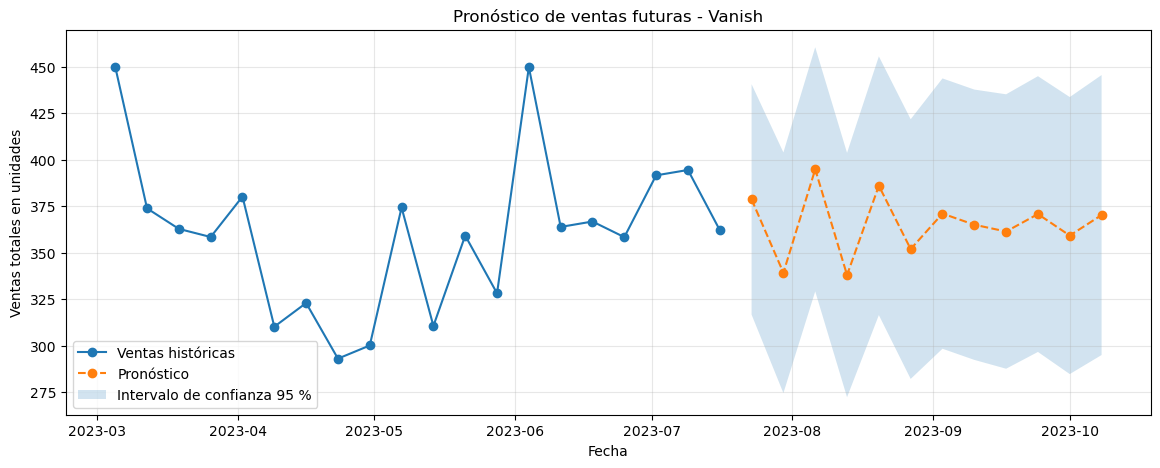

In [225]:
# 94. Visualizar el pronóstico futuro de Vanish

plt.figure(figsize=(14, 5))

plt.plot(
    serie_modelo['VANISH'].iloc[-20:].index,
    serie_modelo['VANISH'].iloc[-20:],
    marker='o',
    label='Ventas históricas'
)

plt.plot(
    pred_futuro_vanish.index,
    pred_futuro_vanish,
    marker='o',
    linestyle='--',
    label='Pronóstico'
)

plt.fill_between(
    pred_futuro_vanish.index,
    ic_vanish.iloc[:, 0],
    ic_vanish.iloc[:, 1],
    alpha=0.2,
    label='Intervalo de confianza 95 %'
)

plt.title('Pronóstico de ventas futuras - Vanish')
plt.xlabel('Fecha')
plt.ylabel('Ventas totales en unidades')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

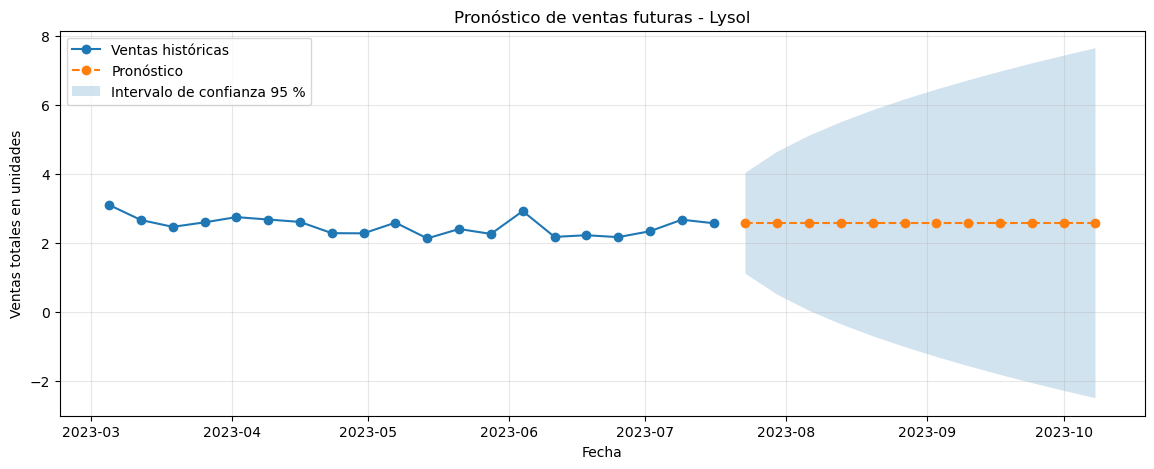

In [227]:
# 95. Visualizar el pronóstico futuro de Lysol

plt.figure(figsize=(14, 5))

plt.plot(
    serie_modelo['LYSOL'].iloc[-20:].index,
    serie_modelo['LYSOL'].iloc[-20:],
    marker='o',
    label='Ventas históricas'
)

plt.plot(
    pred_futuro_lysol.index,
    pred_futuro_lysol,
    marker='o',
    linestyle='--',
    label='Pronóstico'
)

plt.fill_between(
    pred_futuro_lysol.index,
    ic_lysol.iloc[:, 0],
    ic_lysol.iloc[:, 1],
    alpha=0.2,
    label='Intervalo de confianza 95 %'
)

plt.title('Pronóstico de ventas futuras - Lysol')
plt.xlabel('Fecha')
plt.ylabel('Ventas totales en unidades')
plt.legend()
plt.grid(alpha=0.3)

plt.show()